In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.helper_functions import mle_polyfit, root_polyfit

In [200]:
df = pd.read_csv('csvs/final_fit_Run3.csv')

In [201]:
data_region_map = {
    '2022a': (355872, 357950),
    '2022b': (357951, 361500),
    '2022c': (361585, 362167),
    '2022d': (362597, 362760),
    '2023a': (366727, 367516),
    '2023b': (367553, 368822),
    '2023c': (369978, 370776),
    '2024a': (379416, 381544),
    '2024b': (382251, 383855),
    '2024c': (383907, 385515),
    '2024d': (385516, 386025),
    '2024e': (386026, 386951),

    # '2024abc': (379416, 385515),
    # '2024': (379416, 386951),
}

def get_data_region(df, region):
    if region in data_region_map:
        run_min, run_max = data_region_map[region]
        df = df[(df['run'] >= run_min) & (df['run'] <= run_max)]
        return df
    else:
        raise ValueError(f"Region '{region}' not recognized. Available regions: {list(data_region_map.keys())}")

In [202]:
# df_region = get_data_region(df, '2024b')
# print(df_region)
# plt.hist(df_region['run'], bins=50)
# # plt.xlim([361200, 361570])

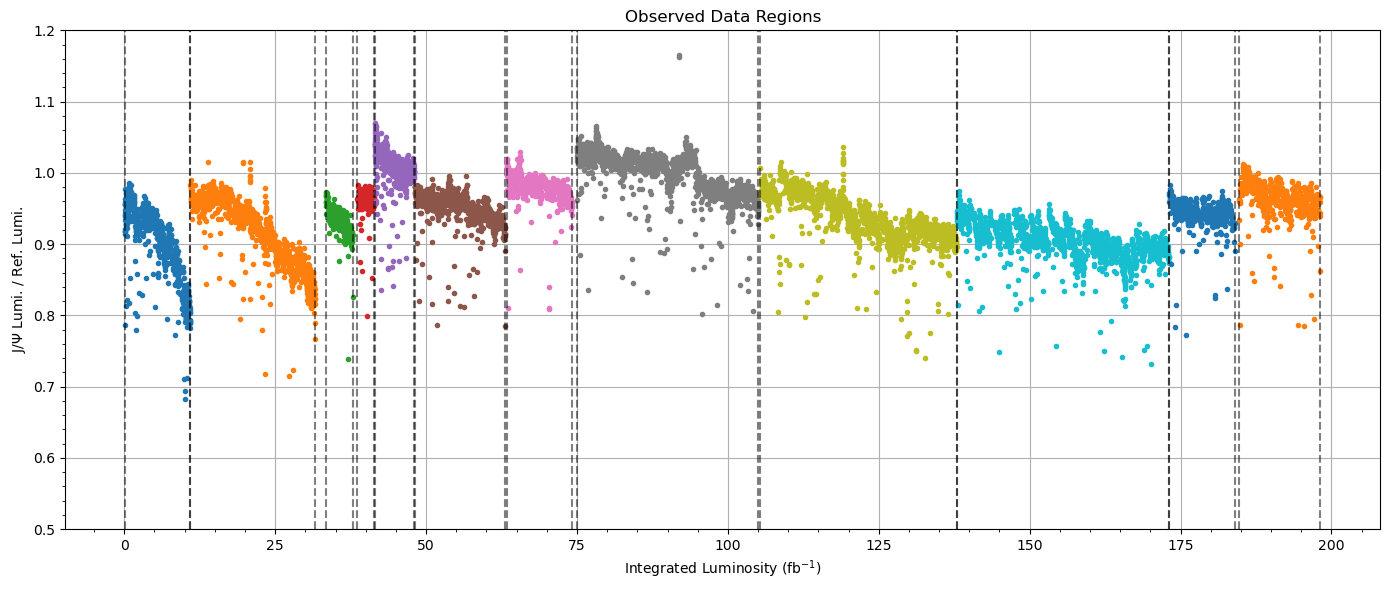


****************************************
Minimizer is Linear / Migrad
Chi2                      =     0.666579
NDf                       =          665
p0                        =     0.966033   +/-   0.00219285  
p1                        =    -0.012342   +/-   0.000373747 

****************************************
Minimizer is Linear / Migrad
Chi2                      =     0.606621
NDf                       =         1067
p0                        =     0.986204   +/-   0.00139846  
p1                        =  -0.00658309   +/-   0.000119028 

****************************************
Minimizer is Linear / Migrad
Chi2                      =    0.0648016
NDf                       =          215
p0                        =     0.957706   +/-   0.00223416  
p1                        =   -0.0118647   +/-   0.000888955 

****************************************
Minimizer is Linear / Migrad
Chi2                      =    0.0719546
NDf                       =          129
p0              

Info in <TCanvas::Print>: png file root_polyfit.png has been created
Info in <TCanvas::Print>: png file root_polyfit.png has been created
Info in <TCanvas::Print>: png file root_polyfit.png has been created
Info in <TCanvas::Print>: png file root_polyfit.png has been created
Info in <TCanvas::Print>: png file root_polyfit.png has been created
Info in <TCanvas::Print>: png file root_polyfit.png has been created
Info in <TCanvas::Print>: png file root_polyfit.png has been created
Info in <TCanvas::Print>: png file root_polyfit.png has been created
Info in <TCanvas::Print>: png file root_polyfit.png has been created
Info in <TCanvas::Print>: png file root_polyfit.png has been created
Info in <TCanvas::Print>: png file root_polyfit.png has been created
Info in <TCanvas::Print>: png file root_polyfit.png has been created


In [206]:
data_fit_summary = []
plt.figure(figsize=(14, 6))

for region, run_range in data_region_map.items():
    df_region = get_data_region(df, region)
    
    if len(df_region) == 0:
        print(f"No data in region {region}, skipping.")
        continue

    xx_orig = df_region['integrated_lumi']
    yy = df_region['final_ratio']

    # Shift x for fitting but keep original for plotting
    xx = xx_orig - xx_orig.min()
    # coeffs, sigma = mle_polyfit(xx, yy, degree=1)
    coeffs, sigma, res = root_polyfit(xx, yy, degree=1)
    coeffs = [c/coeffs[-1] for c in coeffs]  # Normalize by last coeff (constant term)
    sigma = [s/coeffs[-1] for s in sigma]

    # Store coeffs for later use if needed
    data_fit_summary.append({
        'region': region,
        'coeff_data': tuple(coeffs),
        'sigma': sigma,
        'n_points': len(df_region),
        'run_range': run_range,
        'int_lumi_range': (xx_orig.min(), xx_orig.max())
    })

    # Generate fitted curve using original x values
    x_fit = np.linspace(xx_orig.min(), xx_orig.max(), 200)
    y_fit = np.polyval(coeffs, x_fit - xx_orig.min())

    # Plot data points (optional: if you only want fits, remove this)
    plt.plot(xx_orig, yy, '.', label=f'Data {region}')

    # Plot fit curve
    # plt.plot(x_fit, y_fit, '-', label=f'Fit {region}')

    # Mark era boundaries
    plt.axvline(xx_orig.min(), color='k', linestyle='--', alpha=0.5)
    plt.axvline(xx_orig.max(), color='k', linestyle='--', alpha=0.5)
    # plt.text((xx_orig.min() + xx_orig.max()) / 2,
    #          1.1,   # near top
    #          region,
    #          ha='center', va='top', rotation=90)

plt.xlabel('Integrated Luminosity (fb$^{-1}$)')
plt.ylabel('J/$\Psi$ Lumi. / Ref. Lumi.')
plt.title('Observed Data Regions')
# enable minor tick labels
plt.minorticks_on()
# plt.legend()
plt.grid()
plt.tight_layout()
plt.ylim([0.5, 1.2])
plt.show()

fit_df = pd.DataFrame(data_fit_summary)

In [204]:
fit_df.to_csv('data_fit_summary_Run3.csv', index=False)
fit_df

,region,coeff_data,sigma,n_points,run_range,int_lumi_range
0,2022a,"(-0.012775919543468885, 1.0)","[0.00037374679565182263, 0.0021928453996717537]",667,"(355872, 357950)","(0.1536220885685427, 10.93168825443707)"
1,2022b,"(-0.006675177408552969, 1.0)","[0.00011902783841196961, 0.0013984598133254327]",1069,"(357951, 361500)","(10.973137218506215, 31.66698680312783)"
2,2022c,"(-0.012388655563563734, 1.0)","[0.0008889547294504981, 0.002234156820312444]",217,"(361585, 362167)","(33.38299605992437, 37.84586377390419)"
3,2022d,"(0.0019724192411020225, 1.0)","[0.002628264418658902, 0.004366205706191804]",131,"(362597, 362760)","(38.64007797631407, 41.45564732882524)"
4,2023a,"(-0.004451123283469556, 1.0)","[0.001051661641245303, 0.003639888222225145]",452,"(366727, 367516)","(41.51627959393439, 48.06527873826858)"
5,2023b,"(-0.0026624301592177014, 1.0)","[0.00019443891721572962, 0.0016722451182110678]",740,"(367553, 368822)","(48.090800572694114, 63.14581539996469)"
6,2023c,"(-0.002476210290643996, 1.0)","[0.000278387269908189, 0.001742952575685012]",507,"(369978, 370776)","(63.36327137939097, 74.1873480239718)"
7,2024a,"(-0.002331735205800725, 1.0)","[0.00014411187697925778, 0.0024726039809270855]",1502,"(379416, 381544)","(74.98679337792825, 105.04793697590138)"
8,2024b,"(-0.002781643267830591, 1.0)","[7.203276024525343e-05, 0.0013364894308142185]",1417,"(382251, 383855)","(105.39032592192488, 137.8786325105323)"
9,2024c,"(-0.0015407308406327602, 1.0)","[5.941670883828747e-05, 0.0012289916363455897]",1444,"(383907, 385515)","(137.91739082554855, 173.07735836901222)"


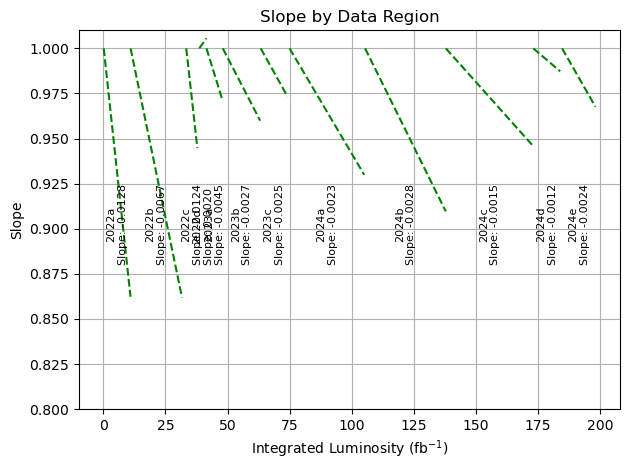

In [205]:
for row in fit_df.itertuples():
    ## show slope
    # plt.plot(row.int_lumi_range, [row.coeff_data[0], row.coeff_data[0]], 'r--', label='Slope')
    # plt.text(np.mean(row.int_lumi_range), row.coeff_data[0]+0.0001,
    #          f"{row.region}",
    #          ha='center', va='bottom', fontsize=8, rotation=0)
    
    ## show line
    x = np.array(row.int_lumi_range)
    y = row.coeff_data[0]*(x-min(row.int_lumi_range)) + row.coeff_data[1]
    plt.plot(x, y, 'g--', label='Slope')
    plt.text(np.mean(x), 0.88, 
             f"{row.region}\nSlope: {row.coeff_data[0]:.4f}",
             ha='center', va='bottom', fontsize=8, rotation=90)

plt.xlabel('Integrated Luminosity (fb$^{-1}$)')
plt.ylabel('Slope')
plt.title('Slope by Data Region')
plt.grid()
plt.ylim([0.8, 1.01])
plt.tight_layout()